<a href="https://colab.research.google.com/github/algaalex/Gaussian-Processes-GANs-GNNs/blob/main/03_cicids_tabular_gan_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2.2 — CICIDS 2017 Synthetic Network Traffic

This notebook loads the Wednesday CICIDS 2017 file(s), explores and cleans the
data, trains separate fully connected GANs for BENIGN and DoS traffic, and
evaluates the generated feature vectors with loss curves, PCA, distribution
distances, correlations and a real-versus-fake classifier.

The separate models make each generated row's class explicit without treating
the text label as a continuous numerical feature.



In [28]:
import sys
import subprocess

# Install/update the official KaggleHub client. The CICIDS files are downloaded
# automatically later; no manual CSV upload or Google Drive mount is required.
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "--upgrade", "kagglehub>=0.3.13"]
)



0

In [29]:
import json
import random
from dataclasses import dataclass
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm



In [30]:
# ----------------------------- Configuration -----------------------------
QUICK_RUN = False
USE_ALL_DAYS_EXTENSION = False  # Optional extra credit: use every CSV and BENIGN vs ATTACK.
SEED = 42
LATENT_DIM = 128
BATCH_SIZE = 512
EPOCHS = 5 if QUICK_RUN else 50
LEARNING_RATE = 2e-4
MAX_ROWS_PER_CLASS = 10_000 if QUICK_RUN else 100_000
EVALUATION_ROWS_PER_CLASS = 2_000 if QUICK_RUN else 10_000
OUTPUT_DIR = Path("outputs/cicids")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
print(f"Using device: {DEVICE}")


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()



Using device: cuda


## 1. Locate and combine the data files

The official KaggleHub client downloads and extracts the public Kaggle copy
automatically into Colab's cache. The code then discovers the Wednesday CSV
file by name. No manual path is used.



In [31]:
def download_cicids_from_kaggle() -> Path:
    """Download and extract the complete public CICIDS Kaggle dataset."""
    dataset_handle = "chethuhn/network-intrusion-dataset"
    print(f"Downloading Kaggle dataset: {dataset_handle}")
    try:
        downloaded_path = kagglehub.dataset_download(
            dataset_handle,
            force_download=False,
        )
    except Exception as error:
        raise RuntimeError(
            "Kaggle download failed. Restart the Colab session and run again. "
            "If Kaggle requests authentication or dataset consent, sign in to "
            "Kaggle and accept the dataset terms before retrying."
        ) from error
    directory = Path(downloaded_path)
    print(f"Dataset downloaded and extracted to: {directory}")
    return directory


data_directory = download_cicids_from_kaggle()
all_csv_paths = sorted(data_directory.rglob("*.csv"))
if not all_csv_paths:
    raise FileNotFoundError(f"No CSV files were found below {data_directory}")

if USE_ALL_DAYS_EXTENSION:
    selected_paths = all_csv_paths
else:
    selected_paths = [path for path in all_csv_paths if "wednesday" in path.name.lower()]
    if not selected_paths:
        available = "\n".join(path.name for path in all_csv_paths[:30])
        raise FileNotFoundError(
            "No Wednesday CSV was found. Available files include:\n" + available
        )

print("Files selected for analysis:")
for path in selected_paths:
    print(" -", path)


def load_and_standardise_csv(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path, low_memory=False)
    frame.columns = frame.columns.astype(str).str.strip()
    return frame


frames = [load_and_standardise_csv(path) for path in tqdm(selected_paths, desc="Loading CSV files")]
raw_data = pd.concat(frames, ignore_index=True, sort=False)
del frames
print(f"Combined raw shape: {raw_data.shape}")
display(raw_data.head())



Using Colab cache for faster access to the 'network-intrusion-dataset' dataset.
Dataset downloaded and extracted to: /kaggle/input/network-intrusion-dataset
Files selected for analysis:
 - /kaggle/input/network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv


Loading CSV files:   0%|          | 0/1 [00:00<?, ?it/s]

Combined raw shape: (692703, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 2. Explore labels and clean features

For the required Wednesday experiment, labels beginning with `DoS` are grouped
as DoS and compared with BENIGN. Heartbleed is excluded because it is not a DoS
label. If the all-days extension is enabled, every non-BENIGN label is grouped
as ATTACK and its original label distribution is also saved.



,label,count,percentage
0,BENIGN,440031,63.523761
1,DoS Hulk,231073,33.358164
2,DoS GoldenEye,10293,1.485918
3,DoS slowloris,5796,0.836722
4,DoS Slowhttptest,5499,0.793847
5,Heartbleed,11,0.001588


,group,count,percentage
0,BENIGN,440031,63.52477
1,DoS,252661,36.47523


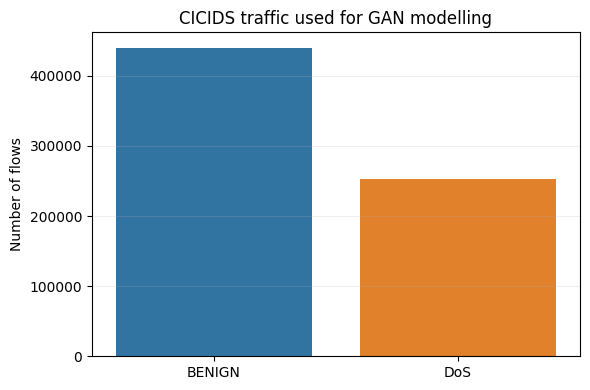

In [32]:
label_candidates = [column for column in raw_data.columns if column.lower() == "label"]
if not label_candidates:
    raise KeyError("A Label column was not found after stripping column names.")
LABEL_COLUMN = label_candidates[0]

raw_labels = raw_data[LABEL_COLUMN].astype(str).str.strip()
original_distribution = raw_labels.value_counts(dropna=False).rename_axis("label").reset_index(name="count")
original_distribution["percentage"] = 100 * original_distribution["count"] / len(raw_labels)
display(original_distribution)
original_distribution.to_csv(OUTPUT_DIR / "original_label_distribution.csv", index=False)

if USE_ALL_DAYS_EXTENSION:
    selected_mask = raw_labels.notna()
    grouped_labels = np.where(raw_labels.eq("BENIGN"), "BENIGN", "ATTACK")
else:
    uppercase_labels = raw_labels.str.upper()
    selected_mask = uppercase_labels.eq("BENIGN") | uppercase_labels.str.startswith("DOS")
    grouped_labels = np.where(uppercase_labels.eq("BENIGN"), "BENIGN", "DoS")

selected_data = raw_data.loc[selected_mask].copy()
selected_data["GAN_GROUP"] = np.asarray(grouped_labels)[selected_mask.to_numpy()]
del raw_data

group_distribution = (
    selected_data["GAN_GROUP"].value_counts().rename_axis("group").reset_index(name="count")
)
group_distribution["percentage"] = 100 * group_distribution["count"] / group_distribution["count"].sum()
display(group_distribution)
group_distribution.to_csv(OUTPUT_DIR / "gan_group_distribution.csv", index=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=group_distribution, x="group", y="count", hue="group", legend=False)
plt.title("CICIDS traffic used for GAN modelling")
plt.ylabel("Number of flows")
plt.xlabel("")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png", dpi=220, bbox_inches="tight")
plt.show()



In [33]:
import json
import random
from dataclasses import dataclass
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

# Sample before expensive cleaning so Colab memory use remains manageable.
sampled_frames: list[pd.DataFrame] = []
for group_name, group_frame in selected_data.groupby("GAN_GROUP"):
    number_to_keep = min(MAX_ROWS_PER_CLASS, len(group_frame))
    sampled_frames.append(group_frame.sample(number_to_keep, random_state=SEED))
    print(f"{group_name}: using {number_to_keep:,} of {len(group_frame):,} available rows")
model_data = pd.concat(sampled_frames, ignore_index=True)
del sampled_frames

# Drop the source text label and generated group from the feature matrix.
feature_frame = model_data.drop(columns=[LABEL_COLUMN, "GAN_GROUP"], errors="ignore")

# Standard CICIDS ML CSVs already contain numerical flow features. Convert any
# object column to numeric and discard identifiers/text columns that become all NaN.
for column in feature_frame.select_dtypes(exclude=[np.number]).columns:
    feature_frame[column] = pd.to_numeric(feature_frame[column], errors="coerce")

feature_frame = feature_frame.replace([np.inf, -np.inf], np.nan)
feature_frame = feature_frame.dropna(axis=1, how="all")
medians = feature_frame.median(numeric_only=True)
feature_frame = feature_frame.fillna(medians)
feature_frame = feature_frame.select_dtypes(include=[np.number]).astype(np.float32)

# Remove constant columns: they add no learnable distribution and can break scaling.
constant_columns = feature_frame.columns[feature_frame.nunique(dropna=False) <= 1].tolist()
feature_frame = feature_frame.drop(columns=constant_columns)
if feature_frame.empty:
    raise ValueError("No numerical non-constant features remain after cleaning.")
if not np.isfinite(feature_frame.to_numpy()).all():
    raise ValueError("Non-finite values remain after cleaning.")

groups = model_data["GAN_GROUP"].reset_index(drop=True)
feature_frame = feature_frame.reset_index(drop=True)
FEATURE_NAMES = feature_frame.columns.tolist()
print(f"Clean model matrix: {feature_frame.shape}; removed {len(constant_columns)} constant columns")

scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_features = scaler.fit_transform(feature_frame).astype(np.float32)

cleaning_summary = {
    "selected_files": [str(path) for path in selected_paths],
    "rows_used": int(len(feature_frame)),
    "number_of_features": int(len(FEATURE_NAMES)),
    "constant_columns_removed": constant_columns,
    "groups": {str(key): int(value) for key, value in groups.value_counts().items()},
    "all_days_extension": USE_ALL_DAYS_EXTENSION,
}
(OUTPUT_DIR / "cleaning_summary.json").write_text(json.dumps(cleaning_summary, indent=2))

BENIGN: using 100,000 of 440,031 available rows
DoS: using 100,000 of 252,661 available rows
Clean model matrix: (200000, 68); removed 10 constant columns


532

## 3. Tabular GAN architecture and training

The generator ends with Tanh because every feature has been scaled to [-1, 1].
The discriminator uses dropout to limit overconfidence on finite tabular data.



In [10]:
class TrafficGenerator(nn.Module):
    def __init__(self, number_of_features: int, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, number_of_features),
            nn.Tanh(),
        )

    def forward(self, noise: torch.Tensor) -> torch.Tensor:
        return self.network(noise)


class TrafficDiscriminator(nn.Module):
    def __init__(self, number_of_features: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(number_of_features, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.25),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 1),
        )

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.network(features).view(-1)


@dataclass
class TrafficGANResult:
    generator: nn.Module
    discriminator: nn.Module
    generator_losses: list[float]
    discriminator_losses: list[float]


def train_traffic_gan(class_features: np.ndarray, class_name: str) -> TrafficGANResult:
    dataset = TensorDataset(torch.from_numpy(class_features))
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=len(dataset) >= BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    generator = TrafficGenerator(class_features.shape[1]).to(DEVICE)
    discriminator = TrafficDiscriminator(class_features.shape[1]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    opt_g = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    g_losses, d_losses = [], []

    for epoch in range(1, EPOCHS + 1):
        generator.train()
        discriminator.train()
        epoch_g, epoch_d = [], []
        progress = tqdm(loader, desc=f"{class_name} epoch {epoch}/{EPOCHS}")
        for (real_batch,) in progress:
            real_batch = real_batch.to(DEVICE, non_blocking=True)
            count = real_batch.size(0)

            opt_d.zero_grad(set_to_none=True)
            real_logits = discriminator(real_batch)
            d_real = criterion(real_logits, torch.ones_like(real_logits))
            fake_batch = generator(torch.randn(count, LATENT_DIM, device=DEVICE))
            fake_logits = discriminator(fake_batch.detach())
            d_fake = criterion(fake_logits, torch.zeros_like(fake_logits))
            d_loss = 0.5 * (d_real + d_fake)
            d_loss.backward()
            opt_d.step()

            opt_g.zero_grad(set_to_none=True)
            generated_logits = discriminator(fake_batch)
            g_loss = criterion(generated_logits, torch.ones_like(generated_logits))
            g_loss.backward()
            opt_g.step()

            epoch_g.append(float(g_loss.item()))
            epoch_d.append(float(d_loss.item()))
            progress.set_postfix(g=f"{g_loss.item():.3f}", d=f"{d_loss.item():.3f}")

        g_losses.append(float(np.mean(epoch_g)))
        d_losses.append(float(np.mean(epoch_d)))

    return TrafficGANResult(generator, discriminator, g_losses, d_losses)


results: dict[str, TrafficGANResult] = {}
real_scaled_by_group: dict[str, np.ndarray] = {}
for group_name in sorted(groups.unique()):
    class_array = scaled_features[groups.to_numpy() == group_name]
    set_seed(SEED)
    results[group_name] = train_traffic_gan(class_array, group_name)
    real_scaled_by_group[group_name] = class_array
    torch.save(results[group_name].generator.state_dict(), OUTPUT_DIR / f"generator_{group_name}.pt")



BENIGN epoch 1/50:   0%|          | 0/195 [00:00<?, ?it/s]

BENIGN epoch 2/50:   0%|          | 0/195 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d77421d93a0><function _MultiProcessingDataLoaderIter.__del__ at 0x7d77421d93a0>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():    if w.is_alive():

             ^ ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
 
        File "/usr/lib

BENIGN epoch 3/50:   0%|          | 0/195 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d77421d93a0>
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d77421d93a0>Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    Traceback (most recent call last):
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
self._shutdown_workers()    
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

     if w.is_alive(): Exception ignored in:  
<function _MultiProcessingDataLoaderIter.__del__ at 0x7d77421d93a0>  
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d77421d93a0>
Exception ignored in: Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7d77421d93a0>
    Traceback (most recent call last):
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        self._shutdown_workers()if w.is_alive():

    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
       if w.is_alive(): 
   ^  ^   ^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self.

DoS epoch 49/50:   0%|          | 0/195 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d77421d93a0>
Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7d77421d93a0>Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    self._shutdown_workers()
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
if w.is_alive():
       if w.is_alive(): 
       ^ ^^ ^ ^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'

  File "/usr/lib/python

DoS epoch 50/50:   0%|          | 0/195 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d77421d93a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    Exception ignored in: self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x7d77421d93a0>
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

Traceback (most recent call last):
    if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

      self._shutdown_workers()  
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  ^    ^if w.is_alive():^^
^ ^^  ^ ^  ^ ^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^
   File "/usr/lib/pyth

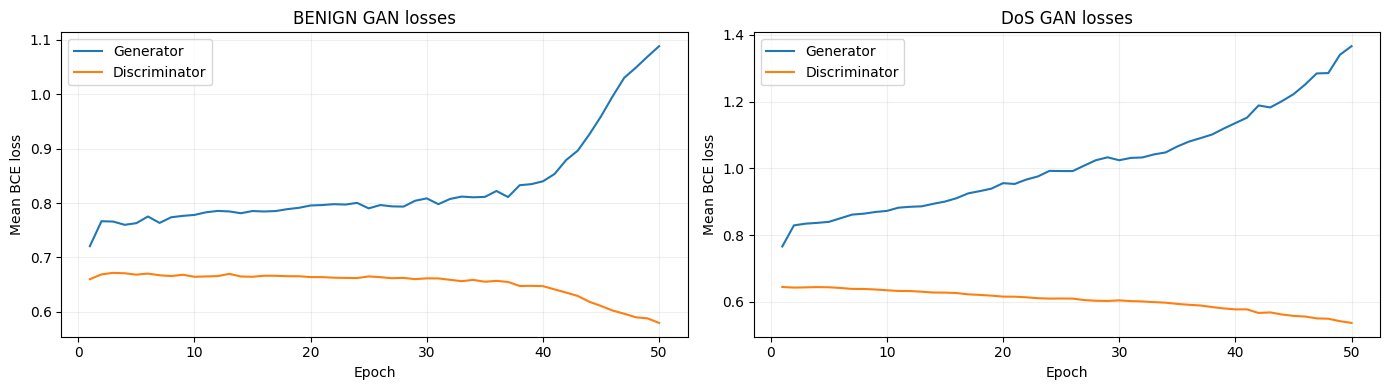

In [11]:
fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 4), squeeze=False)
for axis, (group_name, result) in zip(axes.ravel(), results.items()):
    axis.plot(range(1, EPOCHS + 1), result.generator_losses, label="Generator")
    axis.plot(range(1, EPOCHS + 1), result.discriminator_losses, label="Discriminator")
    axis.set_title(f"{group_name} GAN losses")
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Mean BCE loss")
    axis.grid(alpha=0.2)
    axis.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_loss_curves.png", dpi=220, bbox_inches="tight")
plt.show()

loss_rows = []
for group_name, result in results.items():
    for epoch, (g_loss, d_loss) in enumerate(
        zip(result.generator_losses, result.discriminator_losses), start=1
    ):
        loss_rows.append(
            {"group": group_name, "epoch": epoch, "generator_loss": g_loss, "discriminator_loss": d_loss}
        )
pd.DataFrame(loss_rows).to_csv(OUTPUT_DIR / "training_losses.csv", index=False)



## 4. Generate traffic and compare distributions



In [12]:
@torch.no_grad()
def generate_scaled_features(generator: nn.Module, number_of_rows: int) -> np.ndarray:
    generator.eval()
    batches: list[np.ndarray] = []
    remaining = number_of_rows
    while remaining > 0:
        current = min(2_048, remaining)
        generated = generator(torch.randn(current, LATENT_DIM, device=DEVICE)).cpu().numpy()
        batches.append(generated)
        remaining -= current
    return np.vstack(batches)


generated_scaled_by_group: dict[str, np.ndarray] = {}
synthetic_frames: list[pd.DataFrame] = []
for group_name, result in results.items():
    number_to_generate = min(EVALUATION_ROWS_PER_CLASS, len(real_scaled_by_group[group_name]))
    generated_scaled = generate_scaled_features(result.generator, number_to_generate)
    generated_scaled_by_group[group_name] = generated_scaled
    generated_original_units = scaler.inverse_transform(generated_scaled)
    generated_frame = pd.DataFrame(generated_original_units, columns=FEATURE_NAMES)
    generated_frame["Label"] = group_name
    synthetic_frames.append(generated_frame)

synthetic_traffic = pd.concat(synthetic_frames, ignore_index=True)
synthetic_traffic.to_csv(OUTPUT_DIR / "synthetic_cicids_traffic.csv", index=False)
display(synthetic_traffic.head())



,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,55840.468750,82.254402,0.995588,0.037085,0.000000,0.000000e+00,5.577116,0.000000,0.041353,0.866054,...,30.013506,925.183289,1.961499e+02,188.589096,0.000000,10.728836,0.000000,21.457672,0.000000,BENIGN
1,0.000000,611.543579,1772.340454,1.514316,1584.834473,7.737952e+04,2.098293,60.897392,27.933395,0.000575,...,23.921099,12.397766,1.075968e+03,354886.968750,7063.418457,57.220459,158.125153,42.915344,121.593475,BENIGN
2,1.842352,200264.437500,2873.237549,1574.493286,11297.269531,1.138422e+06,8.409882,1.940782,10.762093,1.657765,...,18.568682,497.460358,1.206754e+06,26162.695312,4362.282227,121829.515625,9380.667969,108125.210938,66472.296875,BENIGN
3,0.428907,1487.731812,100.895699,375.389709,38.815983,5.822068e+04,11.686811,0.012124,0.953339,0.288365,...,20.748753,4.649162,1.675844e+02,96.988678,1071.935913,472.068787,4.273653,826.120422,250.339508,BENIGN
4,0.001950,20384.787109,418.967010,5.451538,503.329071,4.673350e+04,51.625393,69.847298,89.440002,0.382252,...,33.011642,601.291626,3.694475e+02,83690.453125,61237.589844,160.932541,474.375488,185.966492,411.272064,BENIGN


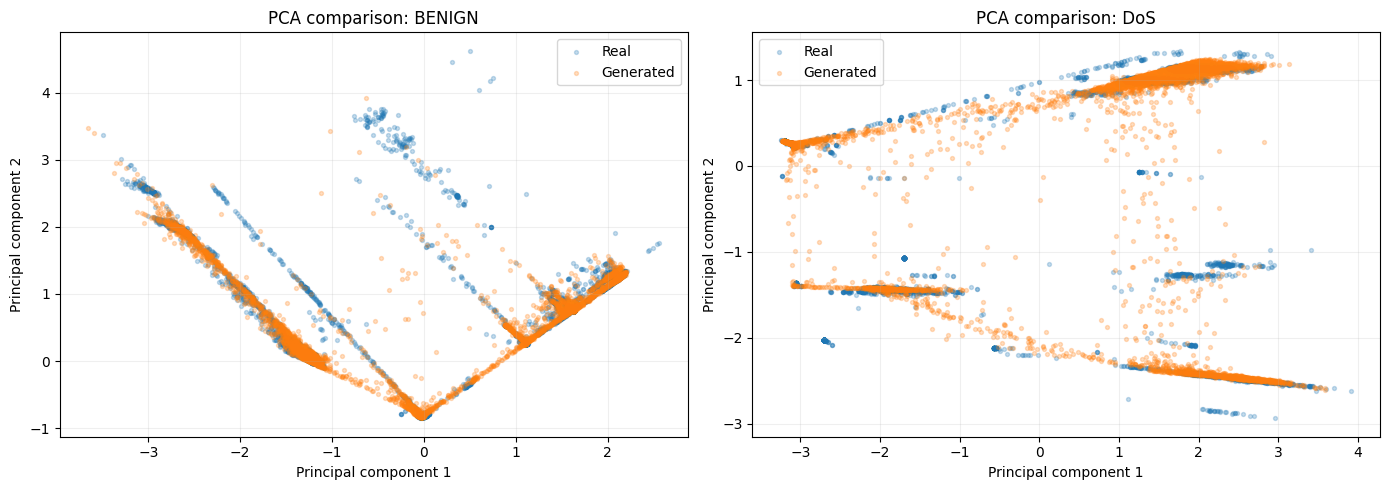

In [13]:
# One PCA panel for each class. PCA is fitted to real and fake data together so
# both use the same axes.
fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 5), squeeze=False)
rng = np.random.default_rng(SEED)
for axis, group_name in zip(axes.ravel(), results):
    real_all = real_scaled_by_group[group_name]
    fake_all = generated_scaled_by_group[group_name]
    n = min(len(real_all), len(fake_all), EVALUATION_ROWS_PER_CLASS)
    real = real_all[rng.choice(len(real_all), n, replace=False)]
    fake = fake_all[rng.choice(len(fake_all), n, replace=False)]
    combined = np.vstack((real, fake))
    projection = PCA(n_components=2, random_state=SEED).fit_transform(combined)
    axis.scatter(projection[:n, 0], projection[:n, 1], s=8, alpha=0.25, label="Real")
    axis.scatter(projection[n:, 0], projection[n:, 1], s=8, alpha=0.25, label="Generated")
    axis.set_title(f"PCA comparison: {group_name}")
    axis.set_xlabel("Principal component 1")
    axis.set_ylabel("Principal component 2")
    axis.legend()
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pca_real_vs_generated.png", dpi=220, bbox_inches="tight")
plt.show()



## 5. Quantitative tabular evaluation

- Median KS and Wasserstein distances compare marginal feature distributions
  (lower is better).
- Correlation error compares feature relationships (lower is better).
- A random-forest AUC measures how easily real and fake rows can be separated;
  0.5 is ideal, while values near 1.0 reveal clear synthetic artefacts.



/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,group,evaluation_rows,median_ks,median_wasserstein_scaled,correlation_error,real_fake_random_forest_auc,final_generator_loss,final_discriminator_loss
0,BENIGN,10000,0.3656,0.0132,0.1967,1.0,1.0882,0.5799
1,DoS,10000,0.3402,0.0163,0.3206,1.0,1.3660,0.5370


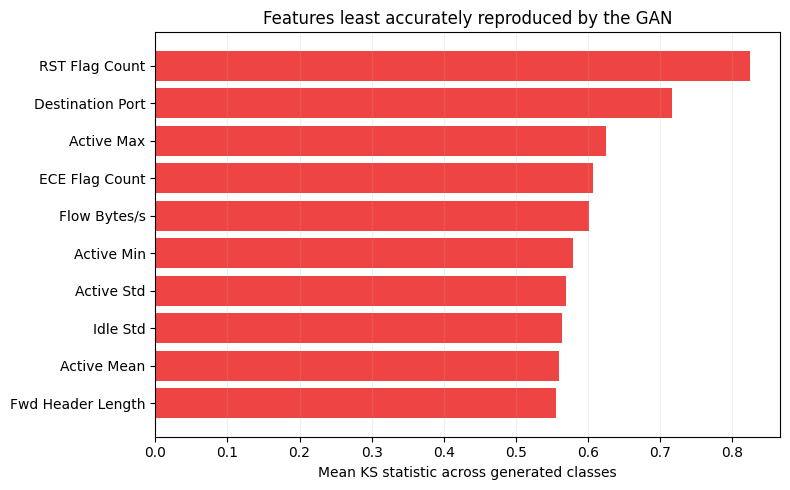

Part 2.2 complete. Outputs saved to /content/outputs/cicids


In [14]:
def real_fake_auc(real: np.ndarray, fake: np.ndarray) -> float:
    n = min(len(real), len(fake), EVALUATION_ROWS_PER_CLASS)
    rng = np.random.default_rng(SEED)
    real = real[rng.choice(len(real), n, replace=False)]
    fake = fake[rng.choice(len(fake), n, replace=False)]
    features = np.vstack((real, fake))
    labels_binary = np.concatenate((np.ones(n), np.zeros(n)))
    x_train, x_test, y_train, y_test = train_test_split(
        features,
        labels_binary,
        test_size=0.3,
        random_state=SEED,
        stratify=labels_binary,
    )
    classifier = RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=SEED,
    )
    classifier.fit(x_train, y_train)
    return float(roc_auc_score(y_test, classifier.predict_proba(x_test)[:, 1]))


metric_rows = []
feature_metric_rows = []
for group_name in results:
    real_all = real_scaled_by_group[group_name]
    fake_all = generated_scaled_by_group[group_name]
    n = min(len(real_all), len(fake_all), EVALUATION_ROWS_PER_CLASS)
    rng = np.random.default_rng(SEED)
    real = real_all[rng.choice(len(real_all), n, replace=False)]
    fake = fake_all[rng.choice(len(fake_all), n, replace=False)]

    ks_values, wasserstein_values = [], []
    for feature_index, feature_name in enumerate(FEATURE_NAMES):
        ks_value = float(ks_2samp(real[:, feature_index], fake[:, feature_index]).statistic)
        w_value = float(wasserstein_distance(real[:, feature_index], fake[:, feature_index]))
        ks_values.append(ks_value)
        wasserstein_values.append(w_value)
        feature_metric_rows.append(
            {
                "group": group_name,
                "feature": feature_name,
                "ks_statistic": ks_value,
                "wasserstein_scaled": w_value,
                "real_mean_scaled": float(real[:, feature_index].mean()),
                "fake_mean_scaled": float(fake[:, feature_index].mean()),
                "real_std_scaled": float(real[:, feature_index].std()),
                "fake_std_scaled": float(fake[:, feature_index].std()),
            }
        )

    real_corr = np.nan_to_num(np.corrcoef(real, rowvar=False))
    fake_corr = np.nan_to_num(np.corrcoef(fake, rowvar=False))
    correlation_error = float(np.linalg.norm(real_corr - fake_corr, ord="fro") / len(FEATURE_NAMES))
    metric_rows.append(
        {
            "group": group_name,
            "evaluation_rows": n,
            "median_ks": float(np.median(ks_values)),
            "median_wasserstein_scaled": float(np.median(wasserstein_values)),
            "correlation_error": correlation_error,
            "real_fake_random_forest_auc": real_fake_auc(real, fake),
            "final_generator_loss": results[group_name].generator_losses[-1],
            "final_discriminator_loss": results[group_name].discriminator_losses[-1],
        }
    )

metrics_table = pd.DataFrame(metric_rows)
feature_metrics = pd.DataFrame(feature_metric_rows)
metrics_table.to_csv(OUTPUT_DIR / "evaluation_metrics.csv", index=False)
feature_metrics.to_csv(OUTPUT_DIR / "feature_level_metrics.csv", index=False)
display(metrics_table.round(4))

# Plot the ten features with the largest KS discrepancy for transparent discussion.
worst_features = (
    feature_metrics.groupby("feature", as_index=False)["ks_statistic"].mean()
    .nlargest(10, "ks_statistic")
    .sort_values("ks_statistic")
)
plt.figure(figsize=(8, 5))
plt.barh(worst_features["feature"], worst_features["ks_statistic"], color="#ef4444")
plt.xlabel("Mean KS statistic across generated classes")
plt.title("Features least accurately reproduced by the GAN")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "worst_feature_discrepancies.png", dpi=220, bbox_inches="tight")
plt.show()

run_summary = {
    "quick_run": QUICK_RUN,
    "all_days_extension": USE_ALL_DAYS_EXTENSION,
    "epochs": EPOCHS,
    "max_rows_per_class": MAX_ROWS_PER_CLASS,
    "latent_dim": LATENT_DIM,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
}
(OUTPUT_DIR / "run_configuration.json").write_text(json.dumps(run_summary, indent=2))
print(f"Part 2.2 complete. Outputs saved to {OUTPUT_DIR.resolve()}")
